<a href="https://www.kaggle.com/code/shamanthakreddymallu/s6e7-tabm?scriptVersionId=335291182" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# TabM

- Same FE / seed-42 folds / original-append protocol as all other notebooks (blendable)
- Plain cross-entropy training; the operating point is set afterward by OOF weight optimization (the proven path in this competition)
- TabM-mini style: k=16 ensemble members sharing one backbone via per-member input scales and per-member heads; loss averaged over members, probabilities averaged at inference
- AMP mixed precision; early stopping on validation loss with best-state restore
- Works on any torch-supported GPU
- Tuned via Optuna (30 trials, 3-fold, weight-opt objective): k=16, hidden 512/256/128, emb cap 24, dropout 0.212, lr 1.61e-3, wd 2.06e-4, batch 4096, cosine t_max=14 fully annealed (max_epochs 19, patience 8)
- Adds signed cliff distances sleep_m6/sleep_m7 to the feature set

In [1]:
# PATHS
TRAIN_PATH    = '/kaggle/input/competitions/playground-series-s6e7/train.csv'
TEST_PATH     = '/kaggle/input/competitions/playground-series-s6e7/test.csv'
SAMPLE_PATH   = '/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv'
ORIGINAL_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/student_health_dataset_50k.csv'

In [2]:
import os, time, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             classification_report)
from itertools import product
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE == 'cuda' else '')

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

train    = pd.read_csv(TRAIN_PATH)
test     = pd.read_csv(TEST_PATH)
original = pd.read_csv(ORIGINAL_PATH)

TARGET   = 'health_condition'
CAT_COLS = ['diet_type', 'stress_level', 'sleep_quality',
            'physical_activity_level', 'smoking_alcohol', 'gender']
NUM_COLS = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
            'step_count', 'exercise_duration', 'water_intake']

for df in [train, test, original]:
    for c in CAT_COLS:
        df[c] = df[c].astype(str).str.strip().str.lower().replace('nan', np.nan)

original[TARGET] = original[TARGET].astype(str).str.strip().str.lower()
original = original.drop(columns=['student_id', 'timestamp'])
print(f'Train {train.shape} | Test {test.shape} | Original {original.shape}')

Device: cuda | Tesla T4
Train (690088, 15) | Test (295753, 14) | Original (50000, 14)


## Feature Engineering (identical to base notebooks)

In [3]:
def engineer_features(df):
    df = df.copy()
    df['stress_x_activity'] = (df['stress_level'].fillna('na') + '_' +
                               df['physical_activity_level'].fillna('na'))
    df['stress_x_sleepq']   = (df['stress_level'].fillna('na') + '_' +
                               df['sleep_quality'].fillna('na'))
    df['stress_x_smoke']    = (df['stress_level'].fillna('na') + '_' +
                               df['smoking_alcohol'].fillna('na'))
    df['sleep_lt6'] = (df['sleep_duration'] < 6).astype(float)
    df['sleep_lt6'] = df['sleep_lt6'].where(df['sleep_duration'].notna())
    df['sleep_ge7'] = (df['sleep_duration'] >= 7).astype(float)
    df['sleep_ge7'] = df['sleep_ge7'].where(df['sleep_duration'].notna())
    df['steps_x_exercise']    = df['step_count'] * df['exercise_duration']
    df['activity_efficiency'] = df['calorie_expenditure'] / df['step_count'].replace(0, np.nan)
    df['sleep_x_steps']       = df['sleep_duration'] * df['step_count']
    df['bmi_band']  = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100], labels=[0, 1, 2, 3]).astype(float)
    df['sleep_dev'] = (df['sleep_duration'] - 7.5).abs()
    # NN-targeted signed cliff distances
    df['sleep_m6'] = df['sleep_duration'] - 6.0
    df['sleep_m7'] = df['sleep_duration'] - 7.0
    return df

train    = engineer_features(train)
test     = engineer_features(test)
original = engineer_features(original)

ENGINEERED_CATS = ['stress_x_activity', 'stress_x_sleepq', 'stress_x_smoke']
ENGINEERED_NUMS = ['sleep_lt6', 'sleep_ge7', 'steps_x_exercise',
                   'activity_efficiency', 'sleep_x_steps', 'bmi_band', 'sleep_dev',
                   'sleep_m6', 'sleep_m7']
ALL_NUM    = NUM_COLS + ENGINEERED_NUMS
MODEL_CATS = CAT_COLS + ENGINEERED_CATS
print(f'{len(ALL_NUM)} numeric + {len(MODEL_CATS)} categorical')

16 numeric + 9 categorical


## NN Preprocessing

In [4]:
# Numerics: median impute + missing flags (float32)
# Categoricals: integer codes with explicit 'missing' level (for embeddings)

med = {c: train[c].median() for c in ALL_NUM}
MISS_FLAGS = []
for df in [train, test, original]:
    for c in ALL_NUM:
        df[f'{c}_isna'] = df[c].isna().astype(np.float32)
        df[c] = df[c].fillna(med[c]).astype(np.float32)
MISS_FLAGS = [f'{c}_isna' for c in ALL_NUM]
NUM_FEATS  = ALL_NUM + MISS_FLAGS

CAT_MAPS, CAT_CARDS = {}, []
for c in MODEL_CATS:
    cats = sorted(pd.concat([train[c], test[c], original[c]]).fillna('missing').unique())
    CAT_MAPS[c] = {v: i for i, v in enumerate(cats)}
    CAT_CARDS.append(len(cats))
    for df in [train, test, original]:
        df[c] = df[c].fillna('missing').map(CAT_MAPS[c]).astype(np.int64)

print(f'{len(NUM_FEATS)} numeric features, cat cardinalities: {CAT_CARDS}')

32 numeric features, cat cardinalities: [4, 4, 4, 4, 4, 4, 16, 16, 16]


## Setup — folds, weight optimizer, tensors

In [5]:
USE_ORIGINAL = True
train['source']    = 'kaggle'
original['source'] = 'original'
COLS = NUM_FEATS + MODEL_CATS
train_augmented = pd.concat(
    [train[COLS + [TARGET, 'source']],
     original[COLS + [TARGET, 'source']]],
    ignore_index=True
)

le    = LabelEncoder()
y_aug = le.fit_transform(train_augmented[TARGET])
print('Class encoding:', dict(zip(le.classes_, range(3))))

N_FOLDS, SEED, N_CLASSES = 5, 42, 3
kag_idx  = np.where(train_augmented['source'] == 'kaggle')[0]
orig_idx = np.where(train_augmented['source'] == 'original')[0]
y_kag    = y_aug[kag_idx]

skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
FOLD_SPLITS = list(skf.split(kag_idx, y_aug[kag_idx]))

def optimize_class_weights(probs, y_true, coarse=31, refine=25):
    grid       = np.exp(np.linspace(np.log(0.5), np.log(40), coarse))
    best_score = balanced_accuracy_score(y_true, probs.argmax(1))
    best_w     = np.ones(3)
    for wf, wu in product(grid, grid):
        w = np.array([1.0, wf, wu])
        s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
        if s > best_score:
            best_score, best_w = s, w
    if refine:
        ff = np.linspace(best_w[1] * 0.8, best_w[1] * 1.2, refine)
        fu = np.linspace(best_w[2] * 0.8, best_w[2] * 1.2, refine)
        for wf, wu in product(ff, fu):
            w = np.array([1.0, wf, wu])
            s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
            if s > best_score:
                best_score, best_w = s, w
    return best_w, best_score

# tensors (numerics standardized with global train stats; flags/codes as-is)
num_mean = train_augmented[ALL_NUM].mean().values.astype(np.float32)
num_std  = train_augmented[ALL_NUM].std().values.astype(np.float32) + 1e-6

def to_tensors(df):
    xn = df[ALL_NUM].values.astype(np.float32)
    xn = (xn - num_mean) / num_std
    xf = df[MISS_FLAGS].values.astype(np.float32)
    xc = df[MODEL_CATS].values.astype(np.int64)
    return (torch.from_numpy(np.hstack([xn, xf])), torch.from_numpy(xc))

X_num_aug, X_cat_aug = to_tensors(train_augmented)
X_num_test, X_cat_test = to_tensors(test)
y_aug_t = torch.from_numpy(y_aug)

# Move everything to GPU immediately (GPU-resident training, no DataLoader transfers)
X_num_aug  = X_num_aug.to(DEVICE)
X_cat_aug  = X_cat_aug.to(DEVICE)
X_num_test = X_num_test.to(DEVICE)
X_cat_test = X_cat_test.to(DEVICE)
y_aug_t    = y_aug_t.to(DEVICE)

print('Tensors ready on device:', X_num_aug.shape, X_cat_aug.shape)

Class encoding: {'at-risk': 0, 'fit': 1, 'unhealthy': 2}
Tensors ready on device: torch.Size([740088, 32]) torch.Size([740088, 9])


## Training Helpers

In [6]:
def run_epoch(model, X_num, X_cat, y, batch_size, training=True, optimizer=None, scaler=None):
    model.train(training)
    total, n = 0.0, 0

    # Shuffle indices on the GPU when training
    if training:
        idx = torch.randperm(len(y), device=DEVICE)
        X_num, X_cat, y = X_num[idx], X_cat[idx], y[idx]

    grad_ctx = torch.enable_grad() if training else torch.no_grad()
    with grad_ctx:
        for i in range(0, len(y), batch_size):
            xb_n = X_num[i:i+batch_size]
            xb_c = X_cat[i:i+batch_size]
            yb   = y[i:i+batch_size]

            # drop_last=True equivalent for BatchNorm stability
            if training and len(yb) < batch_size:
                continue

            with torch.autocast(device_type='cuda', enabled=(DEVICE == 'cuda')):
                loss = model.loss(xb_n, xb_c, yb)

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total += loss.item() * len(yb)
            n += len(yb)

    return total / n if n > 0 else 0

@torch.no_grad()
def predict_proba(model, X_num, X_cat, batch_size=16384):
    model.eval()
    out = []
    for i in range(0, len(X_num), batch_size):
        xb_n = X_num[i:i+batch_size]
        xb_c = X_cat[i:i+batch_size]
        with torch.autocast(device_type='cuda', enabled=(DEVICE == 'cuda')):
            p = model.proba(xb_n, xb_c)
        out.append(p.float().cpu())
    return torch.cat(out).numpy()

def train_one_fold(model, tr_data, val_data, max_epochs, patience, lr,
                   batch_size, fold, weight_decay=1e-4, t_max=None):
    X_num_tr, X_cat_tr, y_tr = tr_data
    X_num_val, X_cat_val, y_val = val_data

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=(t_max if t_max is not None else max_epochs))
    scaler    = torch.amp.GradScaler(enabled=(DEVICE == 'cuda'))

    best_val, best_state, bad = np.inf, None, 0
    for epoch in range(1, max_epochs + 1):
        tr_loss  = run_epoch(model, X_num_tr, X_cat_tr, y_tr, batch_size,
                             training=True, optimizer=optimizer, scaler=scaler)
        val_loss = run_epoch(model, X_num_val, X_cat_val, y_val,
                             batch_size=16384, training=False)
        scheduler.step()

        if val_loss < best_val - 1e-5:
            best_val, bad = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    return epoch, best_val

## Model

In [7]:
class TabM(nn.Module):
    """TabM-mini style: k ensemble members sharing one backbone.
    Member i applies a learned elementwise scale to the input and has its own head;
    training averages the CE loss over members, inference averages probabilities."""
    def __init__(self, n_num, cat_cards, k=16, hidden=(512, 256), p_drop=0.1, emb_cap=24):
        super().__init__()
        self.k = k
        emb_dims = [min(emb_cap, (c + 1) // 2) for c in cat_cards]
        self.embs = nn.ModuleList([nn.Embedding(c, d) for c, d in zip(cat_cards, emb_dims)])
        d_in = n_num + sum(emb_dims)
        self.r = nn.Parameter(torch.randn(k, d_in) * 0.01 + 1.0)   # member input scales
        layers, prev = [], d_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(p_drop)]
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.heads = nn.Parameter(torch.randn(k, prev, 3) * 0.02)  # member heads
        self.head_bias = nn.Parameter(torch.zeros(k, 3))

    def member_logits(self, x_num, x_cat):
        e = [emb(x_cat[:, i]) for i, emb in enumerate(self.embs)]
        x = torch.cat([x_num] + e, dim=1)                      # (B, d)
        B, d = x.shape
        xk = x.unsqueeze(1) * self.r.unsqueeze(0)              # (B, k, d)
        h = self.backbone(xk.reshape(B * self.k, d))           # (B*k, prev)
        h = h.reshape(B, self.k, -1)
        logits = torch.einsum('bkh,kho->bko', h, self.heads) + self.head_bias  # (B, k, 3)
        return logits

    def loss(self, x_num, x_cat, y):
        logits = self.member_logits(x_num, x_cat)              # (B, k, 3)
        B, k, C = logits.shape
        return F.cross_entropy(logits.reshape(B * k, C),
                               y.repeat_interleave(k))

    def proba(self, x_num, x_cat):
        logits = self.member_logits(x_num, x_cat)
        return F.softmax(logits, dim=2).mean(dim=1)

N_NUM = len(NUM_FEATS)
print(TabM(N_NUM, CAT_CARDS))

TabM(
  (embs): ModuleList(
    (0-5): 6 x Embedding(4, 2)
    (6-8): 3 x Embedding(16, 8)
  )
  (backbone): Sequential(
    (0): Linear(in_features=68, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.1, inplace=False)
  )
)


# Training — Stratified 5-Fold

In [8]:
oof_probs  = np.zeros((len(kag_idx), N_CLASSES))
test_probs = np.zeros((len(test), N_CLASSES))
fold_scores = []

for fold, (tr_kag, val_kag) in enumerate(FOLD_SPLITS, 1):
    t0 = time.time()
    set_seed(SEED + fold)
    tr_idx  = np.concatenate([kag_idx[tr_kag], orig_idx])
    val_idx = kag_idx[val_kag]

    tr_data  = (X_num_aug[tr_idx], X_cat_aug[tr_idx], y_aug_t[tr_idx])
    val_data = (X_num_aug[val_idx], X_cat_aug[val_idx], y_aug_t[val_idx])

    # Tuned config (Optuna best, final 5-fold retrain OOF 0.94794)
    model = TabM(N_NUM, CAT_CARDS, k=16, hidden=(512, 256, 128),
                 p_drop=0.212, emb_cap=24).to(DEVICE)

    n_epochs, best_val = train_one_fold(model, tr_data, val_data,
                                        max_epochs=19, patience=8,
                                        lr=1.61e-3, batch_size=4096, fold=fold,
                                        weight_decay=2.06e-4, t_max=14)

    val_p = predict_proba(model, X_num_aug[val_idx], X_cat_aug[val_idx])
    oof_probs[val_kag] = val_p
    test_probs += predict_proba(model, X_num_test, X_cat_test) / N_FOLDS

    s = balanced_accuracy_score(y_aug[val_idx], val_p.argmax(1))
    fold_scores.append(s)
    print(f'Fold {fold}: balanced_acc = {s:.5f}  (epochs={n_epochs}, val_loss={best_val:.5f}, {(time.time()-t0)/60:.1f} min)')

raw_oof_score = balanced_accuracy_score(y_kag, oof_probs.argmax(1))
print(f'\nRaw OOF (argmax): {raw_oof_score:.5f}')
print(f'CV mean         : {np.mean(fold_scores):.5f} +/- {np.std(fold_scores):.5f}')

np.save('oof_tabm.npy', oof_probs)
np.save('test_tabm.npy', test_probs)

Fold 1: balanced_acc = 0.86889  (epochs=19, val_loss=0.09254, 1.0 min)
Fold 2: balanced_acc = 0.87549  (epochs=19, val_loss=0.09219, 1.0 min)
Fold 3: balanced_acc = 0.87012  (epochs=19, val_loss=0.09443, 0.9 min)
Fold 4: balanced_acc = 0.86934  (epochs=19, val_loss=0.09296, 0.9 min)
Fold 5: balanced_acc = 0.87519  (epochs=19, val_loss=0.09549, 1.0 min)

Raw OOF (argmax): 0.87180
CV mean         : 0.87180 +/- 0.00291


# Decision-Rule Optimization on OOF

In [9]:
global_w, opt_oof_score = optimize_class_weights(oof_probs, y_kag)
print(f'Raw  OOF balanced accuracy : {raw_oof_score:.5f}')
print(f'Optimized weights          : {dict(zip(le.classes_, global_w.round(4)))}')
print(f'Opt. OOF balanced accuracy : {opt_oof_score:.5f}   (+{opt_oof_score - raw_oof_score:.5f})')

Raw  OOF balanced accuracy : 0.87180
Optimized weights          : {'at-risk': np.float64(1.0), 'fit': np.float64(13.5984), 'unhealthy': np.float64(13.6761)}
Opt. OOF balanced accuracy : 0.94795   (+0.07615)


## Segmented Decision Rule (diagnostic)

In [10]:
# Segmented decision rule (diagnostic; strict margin decides submission)
train_kag = train.reset_index(drop=True)
stress_missing_code = CAT_MAPS['stress_level']['missing']
stress_missing_tr = (train_kag['stress_level'] == stress_missing_code).values
stress_missing_te = (test['stress_level'] == stress_missing_code).values

seg_weights = {}
for name, mask in [('present', ~stress_missing_tr), ('missing', stress_missing_tr)]:
    w, s = optimize_class_weights(oof_probs[mask], y_kag[mask])
    seg_weights[name] = w
    print(f'{name:8s}: weights={w.round(3)}  seg_balanced_acc={s:.5f}')

preds_seg = np.empty(len(y_kag), dtype=int)
preds_seg[~stress_missing_tr] = (oof_probs[~stress_missing_tr] * seg_weights['present']).argmax(1)
preds_seg[stress_missing_tr]  = (oof_probs[stress_missing_tr]  * seg_weights['missing']).argmax(1)
seg_oof_score = balanced_accuracy_score(y_kag, preds_seg)
print(f'\nGlobal-weight OOF : {opt_oof_score:.5f}')
print(f'Segmented OOF     : {seg_oof_score:.5f}   ({seg_oof_score - opt_oof_score:+.5f})')

present : weights=[ 1.    20.555 15.587]  seg_balanced_acc=0.96043
missing : weights=[ 1.    12.892 12.892]  seg_balanced_acc=0.85686

Global-weight OOF : 0.94795
Segmented OOF     : 0.94800   (+0.00005)


# Post-Modeling Analysis

              precision    recall  f1-score   support

     at-risk       0.99      0.93      0.96    592561
         fit       0.74      0.95      0.83     39803
   unhealthy       0.67      0.97      0.79     57724

    accuracy                           0.94    690088
   macro avg       0.80      0.95      0.86    690088
weighted avg       0.95      0.94      0.94    690088



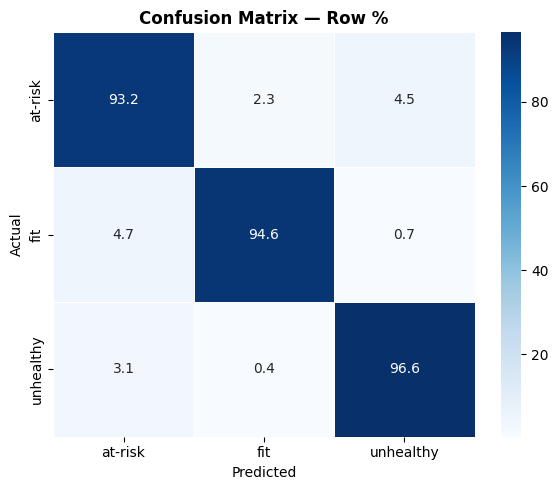

stress present  : balanced_acc = 0.96040   (n=607,277)
stress MISSING  : balanced_acc = 0.85668   (n=82,811)


In [11]:
probs_w   = oof_probs * global_w
preds_kag = probs_w.argmax(1)

cm_pct = confusion_matrix(y_kag, preds_kag, normalize='true') * 100
print(classification_report(y_kag, preds_kag, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix — Row %', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

for name, mask in [('stress present', ~stress_missing_tr),
                   ('stress MISSING', stress_missing_tr)]:
    s = balanced_accuracy_score(y_kag[mask], preds_kag[mask])
    print(f'{name:16s}: balanced_acc = {s:.5f}   (n={mask.sum():,})')

# Submission

In [12]:
STRICT_MARGIN = 0.0005
if seg_oof_score > opt_oof_score + STRICT_MARGIN:
    test_w = np.empty_like(test_probs)
    test_w[~stress_missing_te] = test_probs[~stress_missing_te] * seg_weights['present']
    test_w[stress_missing_te]  = test_probs[stress_missing_te]  * seg_weights['missing']
    print(f'Using SEGMENTED weights')
else:
    test_w = test_probs * global_w
    print(f'Using GLOBAL weights: {global_w.round(3)}')

labels = le.inverse_transform(test_w.argmax(1))

sub = pd.read_csv(SAMPLE_PATH)
sub[TARGET] = labels
sub.to_csv('submission.csv', index=False)
print('Saved: submission.csv (+ oof_tabm.npy / test_tabm.npy for blending)')
print('\nPredicted class distribution (test):')
print(pd.Series(labels).value_counts().to_string())

Using GLOBAL weights: [ 1.    13.598 13.676]
Saved: submission.csv (+ oof_tabm.npy / test_tabm.npy for blending)

Predicted class distribution (test):
at-risk      238707
unhealthy     35390
fit           21656
